# Exploring ObsCore dataset metadata

This notebook retrieves a sample of CTAO SDC ObsCore metadata and creates simple summary plots. The goal is not a scientific analysis yet, but a starting point for dataset exploration.

In [2]:
from textwrap import dedent

from astropy import constants as const
from astropy import units as u

import matplotlib.pyplot as plt
import pandas as pd
import pyvo as vo

TAP_URL = "http://voparis-tap-he.obspm.fr/tap"
OBSCORE_TABLE = "ctao_sdc.obscore"

service = vo.dal.TAPService(TAP_URL)

In [3]:
query = dedent(f"""
    SELECT TOP 500
        obs_id,
        dataproduct_type,
        calib_level,
        target_name,
        s_ra,
        s_dec,
        t_min,
        t_max,
        em_min,
        em_max
    FROM {OBSCORE_TABLE}
""")

df = service.search(query).to_table().to_pandas()

df.head()

,obs_id,dataproduct_type,calib_level,target_name,s_ra,s_dec,t_min,t_max,em_min,em_max
0,5000000396,event-list,2,KSP: Transients-GRB - Event #355,107.177099,-3.099358,61797.110564,61797.168377,6.213929e-21,9.848414e-17
1,5000000379,event-list,2,EGal Survey,216.770682,18.639032,61796.258785,61796.272673,6.213929e-21,9.848414e-17
2,5000000400,event-list,2,AGN-Flares-External - 3C 279,194.750115,-5.788880,61797.179991,61797.185778,6.213929e-21,9.848414e-17
3,5000000050,event-list,2,AGN-LTM - 1ES 1426+428,218.087902,42.668573,61773.266262,61773.271470,6.213929e-21,9.848414e-17
4,5000000545,event-list,2,EGal Survey,199.126962,20.474524,61801.046042,61801.091701,6.213929e-21,9.848414e-17


In [4]:
df["duration_days"] = df["t_max"] - df["t_min"]
df["duration_seconds"] = df["duration_days"] * 86400

df["em_min_tev"] = (
    (const.h * const.c / (df["em_max"].to_numpy() * u.m))
    .to(u.TeV)
    .value
)

df["em_max_tev"] = (
    (const.h * const.c / (df["em_min"].to_numpy() * u.m))
    .to(u.TeV)
    .value
)

df[["obs_id", "target_name", "duration_seconds", "em_min_tev", "em_max_tev"]].head()

,obs_id,target_name,duration_seconds,em_min_tev,em_max_tev
0,5000000396,KSP: Transients-GRB - Event #355,4995.0,0.012589,199.526243
1,5000000379,EGal Survey,1200.0,0.012589,199.526243
2,5000000400,AGN-Flares-External - 3C 279,500.0,0.012589,199.526243
3,5000000050,AGN-LTM - 1ES 1426+428,450.0,0.012589,199.526243
4,5000000545,EGal Survey,3945.0,0.012589,199.526243


In [7]:
df["dataproduct_type"].value_counts(dropna=False)

dataproduct_type
event-list    356
Name: count, dtype: int64

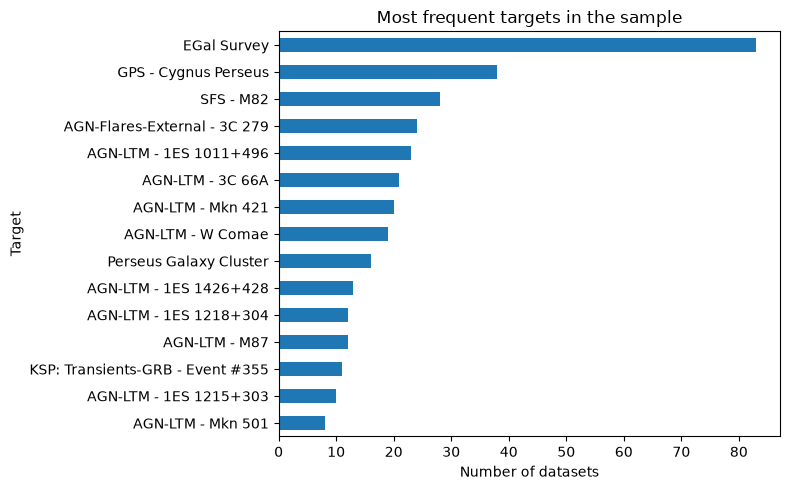

In [8]:
target_counts = df["target_name"].fillna("Unknown").value_counts().head(15)

ax = target_counts.sort_values().plot(kind="barh", figsize=(8, 5))
ax.set_xlabel("Number of datasets")
ax.set_ylabel("Target")
ax.set_title("Most frequent targets in the sample")
plt.tight_layout()

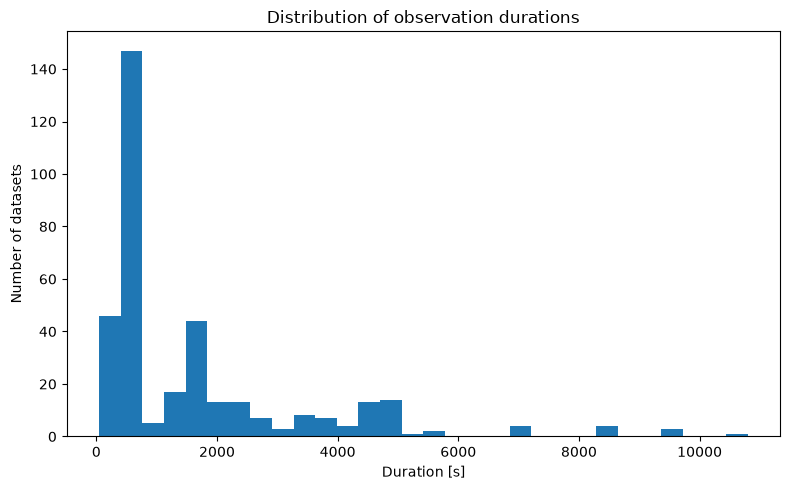

In [9]:
ax = df["duration_seconds"].dropna().plot(kind="hist", bins=30, figsize=(8, 5))
ax.set_xlabel("Duration [s]")
ax.set_ylabel("Number of datasets")
ax.set_title("Distribution of observation durations")
plt.tight_layout()

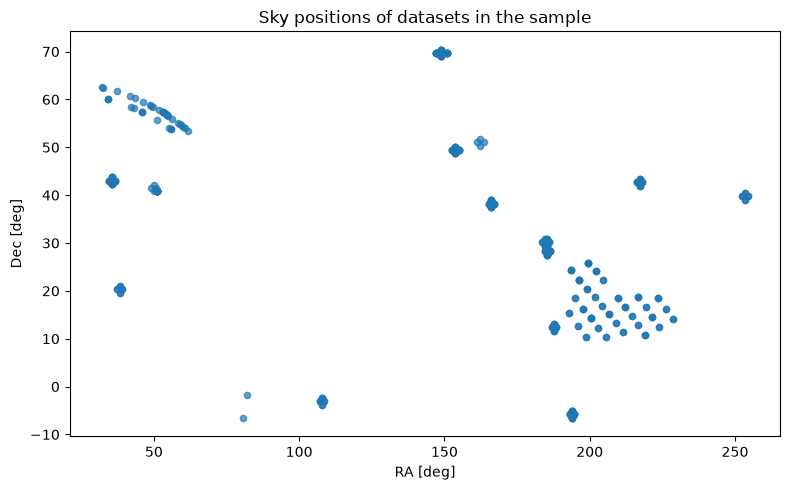

In [10]:
plot_df = df.dropna(subset=["s_ra", "s_dec"])

ax = plot_df.plot(
    kind="scatter",
    x="s_ra",
    y="s_dec",
    figsize=(8, 5),
    alpha=0.7,
)
ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title("Sky positions of datasets in the sample")
plt.tight_layout()

In [14]:
df[["em_min", "em_max", "em_min_tev", "em_max_tev"]].drop_duplicates()

,em_min,em_max,em_min_tev,em_max_tev
0,6.213929e-21,9.848414e-17,0.012589,199.526243


In [15]:
df[["em_min_tev", "em_max_tev"]].drop_duplicates().shape

(1, 2)

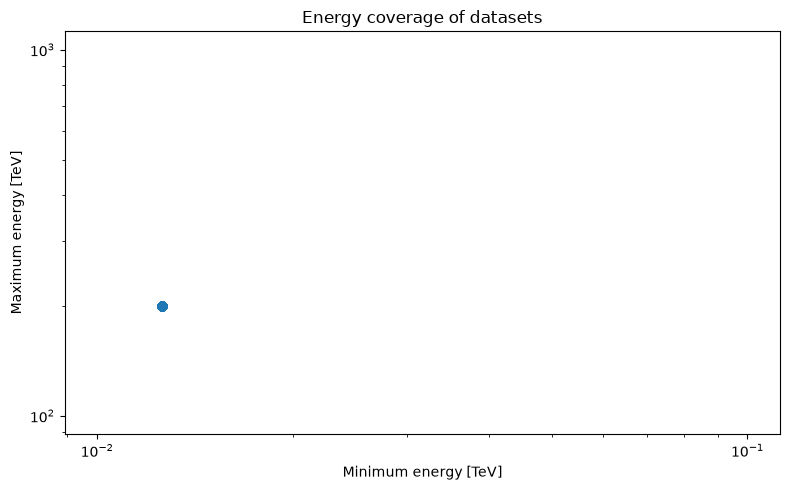

In [11]:
energy_df = df.dropna(subset=["em_min_tev", "em_max_tev"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(energy_df["em_min_tev"], energy_df["em_max_tev"], alpha=0.7)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Minimum energy [TeV]")
ax.set_ylabel("Maximum energy [TeV]")
ax.set_title("Energy coverage of datasets")
plt.tight_layout()

In this sample, many datasets may share the same energy coverage metadata.
If only one point is visible, it means that the energy ranges overlap or are identical for the selected rows.